<a href="https://colab.research.google.com/github/UmymaM/ml-dl-cv-fundamentals/blob/main/face-classification/face_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=101bf0a1be77d82a1788b2bfa0631c6ad1495f6788d10460c6c0bea7c27d2d28
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import pytorch_grad_cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

In [4]:
# pytorch wont use the gpu automatically even if its enabled
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [5]:
image_size=224
# resnet50 pretrained is trained on imagenet which uses 224*224 sized images
# well resize our entire dataset to match the model schema
train_transform=transforms.Compose( #composing several transforms together to augment training ds
    [transforms.Resize((image_size,image_size)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])  ])

test_transform=transforms.Compose(
    [transforms.Resize((image_size,image_size)),
    transforms.ToTensor(), #no augmentation for test ds
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])  ])

In [9]:
!kaggle datasets download -d atulanandjha/lfwpeople

Dataset URL: https://www.kaggle.com/datasets/atulanandjha/lfwpeople
License(s): GNU Lesser General Public License 3.0
100% 232M/232M [00:01<00:00, 123MB/s]



In [10]:
import zipfile
zipfile=zipfile.ZipFile('lfwpeople.zip')
zipfile.extractall()
zipfile.close()

In [15]:
import tarfile

# Path to the tgz file
tgz_file_path = '/content/lfw-funneled.tgz'

# Directory to extract to
extract_dir = '/content/'

# Open the tgz file in read mode ('r:gz')
with tarfile.open(tgz_file_path, 'r:gz') as tar:
    # Extract all contents to the specified directory
    tar.extractall(path=extract_dir)

/tmp/ipykernel_6489/1858224901.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


Extracted /content/lfw-funneled.tgz to /content/


In [17]:
dataset = datasets.ImageFolder(root='/content/lfw_funneled',
                  transform=train_transform)

In [21]:
# calculating sizes of train test datasets for an 80 20 split
train_ds=int(0.8*len(dataset))
val_ds=len(dataset)-train_ds

In [22]:
print(f"Length of Training Data: {train_ds} \n Length of Validation Data: {val_ds}")

Length of Training Data: 10586 
 Length of Validation Data: 2647


In [23]:
train_data,val_data=random_split(dataset,[train_ds,val_ds])

In [24]:
val_data.dataset.transform=test_transform

In [25]:
train_loader=DataLoader(train_data,batch_size=16, shuffle=True)
val_loader=DataLoader(val_data,batch_size=16)

In [26]:
# laoding pretrained model
model=models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s]


In [31]:
# freezing all layers of the network
for param in model.parameters():
  param.requires_grad=False

In [33]:
len(dataset.classes)
# 5749 classes in the lfwpeople ds

5749

In [34]:
model.fc=nn.Linear(model.fc.in_features,len(dataset.classes))

In [35]:
model.to(device=device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [36]:
# loss function and optimizer
criteria=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [37]:
for epoch in range(3):
  model.train()
  total_loss=0
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    output=model(images)
    loss=criteria(output,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss+=loss.item()
  print(f"[Warmup] Epoch {epoch+1}, Loss: {total_loss:.4f}")


[Warmup] Epoch 1, Loss: 6700.7798
[Warmup] Epoch 2, Loss: 3401.0978
[Warmup] Epoch 3, Loss: 1710.5028


In [39]:
# unfreezing the last layer
for param in model.layer4.parameters():
  param.requires_grad=True
# new optimizer
optimizer = optim.Adam([
    {"params": model.fc.parameters(), "lr": 1e-3},
    {"params": model.layer4.parameters(), "lr": 1e-4}
])

In [40]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        outputs =model(images)
        loss=criteria(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    # validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            outputs=model(images)
            _,preds=torch.max(outputs,1)
            total+=labels.size(0)
            correct+=(preds==labels).sum().item()

    acc = 100 * correct / total
    scheduler.step()

    print(f"[FineTune] Epoch {epoch+1}, Loss: {total_loss:.4f}, Val Acc: {acc:.2f}%")

[FineTune] Epoch 1, Loss: 2332.2229, Val Acc: 23.23%
[FineTune] Epoch 2, Loss: 126.5214, Val Acc: 24.18%
[FineTune] Epoch 3, Loss: 63.0463, Val Acc: 26.56%
[FineTune] Epoch 4, Loss: 108.8643, Val Acc: 22.48%
[FineTune] Epoch 5, Loss: 345.7057, Val Acc: 23.61%


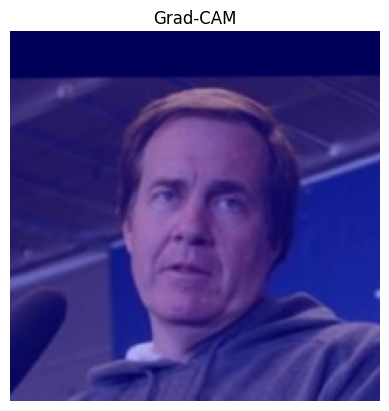

In [45]:
def denormalize(image):
  mean=np.array([0.485, 0.456, 0.406])
  std=np.array([0.229, 0.224, 0.225])
  image=image.numpy().transpose(1,2,0)
  return std*image+mean

model.eval()

target_layer = model.layer4[-1]
cam = GradCAM(model=model, target_layers=[target_layer])

image, label = dataset[1200]
input_tensor = image.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

img = denormalize(image)
visualization = show_cam_on_image(img.astype(np.float32), grayscale_cam, use_rgb=True)

plt.imshow(visualization)
plt.title("Grad CAM")
plt.axis("off")
plt.show()